# Modeling — Factor Regression (Linear Regression)

Fits the four-factor linear model on a time-ordered train/test split and diagnoses the residuals.

In [1]:
# --- run me first ---
from pathlib import Path
import os, sys
if Path.cwd().name == 'notebooks':
    os.chdir('..')
ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print('working from:', ROOT.name)

working from: project


In [2]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from src import config, utils

In [3]:
df = utils.load_dataframe(config.DATA_DIR_PROCESSED / 'cleaned_data.csv')
FEATURES = ['mkt_excess', 'size', 'value', 'momentum']
X = df[FEATURES].to_numpy(); y = df['asset_excess'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

print('R2 = %.4f   RMSE = %.5f' % (r2_score(y_test, y_pred), np.sqrt(mean_squared_error(y_test, y_pred))))
print('\ncoefficients:')
for name, b in zip(FEATURES, model.coef_):
    print(f'  {name:12s} {b:+.4f}')
print(f'  {"intercept":12s} {model.intercept_:+.6f}')

R2 = 0.5068   RMSE = 0.01019

coefficients:
  mkt_excess   +1.0231
  size         +0.2656
  value        -0.2274
  momentum     +0.4591
  intercept    +0.000245


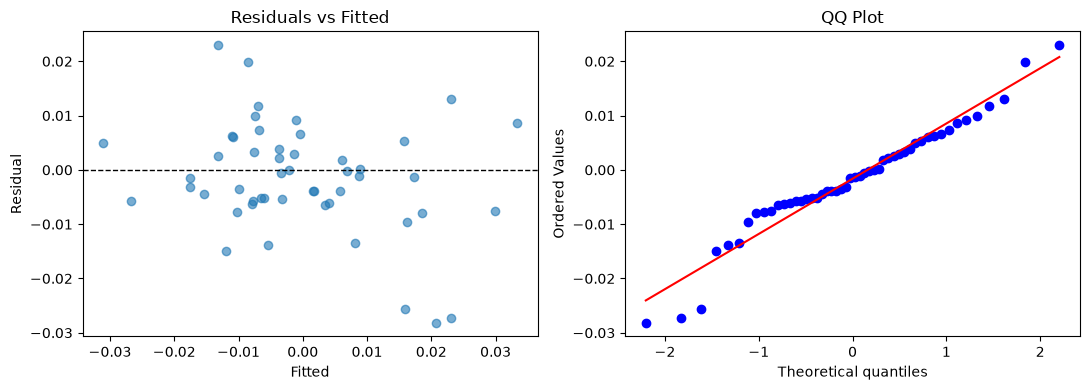

In [4]:
resid = y_test - y_pred
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(y_pred, resid, alpha=0.6); axes[0].axhline(0, color='black', ls='--', lw=1)
axes[0].set_xlabel('Fitted'); axes[0].set_ylabel('Residual'); axes[0].set_title('Residuals vs Fitted')
st.probplot(resid, dist='norm', plot=axes[1]); axes[1].set_title('QQ Plot')
fig.tight_layout(); plt.show()

**Interpretation.** The market factor is the dominant exposure (largest coefficient). Residuals are roughly centered and symmetric with slightly heavy tails (heteroskedastic noise), so the model is reasonable for prediction but should not be read as a precise, normal-theory inference.